# Task-anchored states in hippocampal place cells (Pettit et al. 2022)

Everything else in this collection either validates the trial-clustering
anchoring classifier against **simulated** ground truth (the net7 RNN) or
applies it to MEC ephys sessions where anchoring must be **inferred** (no
ground truth exists). The Pettit2022 dataset -- calcium imaging from
hippocampal CA1 place cells, converted into this project's file format in
`scripts/figures/AnchorDynamics2026/`'s companion conversion
pipeline -- offers something neither of those can: a **real,
experimenter-controlled cue-visibility manipulation** (some trials are
genuinely cue-blind, `fraction_visible` in the trials table), in real
biological data, in a completely different brain region and recording
modality (hippocampus, calcium imaging) from everything else here (MEC,
electrophysiology).

This notebook asks the direct question: **does the same classifier, with
zero changes to its core logic, recover this real biological ground
truth?**

Two things had to be adapted, not the classification logic itself:
1. Calcium activity is continuous, not spike times -- position-binning uses
   `nap.compute_1d_tuning_curves_continuous` (as in
   `figure5_pupil_arousal.ipynb`) instead of the spike-based
   `nap.compute_1d_tuning_curves`.
2. This function vectorizes over every column of a TsdFrame in one call --
   passing the whole population at once instead of looping per cell is
   dramatically faster (confirmed: 3.7s for 1144 cells vs. an estimated
   ~1hr looping one cell at a time).

In [1]:
import sys, os, glob
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import pynapple as nap
from scipy.ndimage import gaussian_filter, median_filter
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.stats import spearmanr, mannwhitneyu

plt.rcParams['font.family'] = 'Arial'

PETTIT_ROOT = os.path.expanduser('~/Downloads/Pettit2022')
FIGPATH = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/'

ANCH_COLOR, NONANCH_COLOR = '#9d5391', '#5f9ea0'   # matches the rest of this collection
TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)

TL, BS = 200.0, 2.0   # cm; matches COHORT12's vr_tl/bs convention (this dataset's track
                       # converts to ~200cm too, confirmed against the source Virmen units)
BPT = int(TL / BS)


def session_path(mouse, date):
    d = os.path.join(PETTIT_ROOT, mouse, f'D{date}', 'VR')
    beh = os.path.join(d, f'sub-{mouse}_day-{date}_ses-VR_beh.nwb')
    clusters = os.path.join(d, f'sub-{mouse}_day-{date}_ses-VR_srt-deconv_clusters.npz')
    return beh, clusters


def list_all_sessions():
    nwb_files = sorted(glob.glob(os.path.join(PETTIT_ROOT, '*', '*', 'VR', '*_beh.nwb')))
    out = []
    for f in nwb_files:
        parts = os.path.basename(f).replace('sub-', '').split('_day-')
        mouse = parts[0]
        date = parts[1].split('_ses-')[0]
        out.append((mouse, date))
    return out


print(f'{len(list_all_sessions())} Pettit2022 sessions available, track length={TL}cm, bins/trial={BPT}')


39 Pettit2022 sessions available, track length=200.0cm, bins/trial=100


In [2]:
"""
Adapt the trial-clustering anchoring classifier (trial_cluster_anchoring.ipynb)
to continuous calcium activity instead of spike counts.

Position binning: COHORT12's spike-based rate maps use
`nap.compute_1d_tuning_curves` (point-process). Calcium activity is already
continuous, so `nap.compute_1d_tuning_curves_continuous` is the right
counterpart (same function already used for eye position/pupil dilation in
figure5_pupil_arousal.ipynb). Critically, this function vectorizes
over ALL columns of a TsdFrame in one call (the internal loop is over
position bins, not cells) -- passing the whole population's TsdFrame at
once instead of looping per cell is ~1000x faster in practice (3.7s for
1144 cells vs. an estimated ~1hr looping one cell at a time).

Classification: identical trial_cluster_labels() logic to
trial_cluster_anchoring.ipynb (per-trial correlation matrix -> 2-means on
mean correlation -> median-filter phase-aliasing correction), applied per
cell to its calcium activity profile instead of firing rate.
"""
def build_position_binned_activity(beh, clusters):
    travel = beh['travel']
    n_bins = int((np.nanmax(travel.values) // TL + 1) * TL / BS)
    max_bound = int((np.nanmax(travel.values) // TL + 1) * TL)
    n_trials = n_bins // BPT

    tc_all = np.array(nap.compute_1d_tuning_curves_continuous(
        clusters, travel, nb_bins=n_bins, minmax=[0, max_bound], ep=beh['moving']))
    n_cells = tc_all.shape[1]
    tc_all = tc_all[:n_trials * BPT].reshape(n_trials, BPT, n_cells)  # [trial, bin, cell]
    return tc_all, n_trials


def trial_cluster_labels(raw_trials, min_activity=1e-6, min_valid_trials=6, smooth_sigma=1.5, medfilt_size=5):
    n_trials = raw_trials.shape[0]
    smoothed = np.array([gaussian_filter(np.nan_to_num(raw_trials[t]).astype(np.float64), sigma=smooth_sigma)
                          for t in range(n_trials)])
    activity = smoothed.sum(axis=1)
    valid = activity > min_activity
    labels = np.full(n_trials, np.nan)
    mean_corr_full = np.full(n_trials, np.nan)
    sil = np.nan
    if valid.sum() < min_valid_trials:
        return labels, mean_corr_full, smoothed, sil
    C = np.corrcoef(smoothed[valid])
    mean_corr = (C.sum(axis=1) - 1) / (C.shape[0] - 1)
    km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(mean_corr.reshape(-1, 1))
    anchored_cluster = np.argmax(km.cluster_centers_.ravel())
    valid_labels = (km.labels_ == anchored_cluster).astype(float)
    if len(np.unique(km.labels_)) > 1:
        sil = silhouette_score(mean_corr.reshape(-1, 1), km.labels_)
    labels[valid] = valid_labels
    labels[~valid] = 0.0
    if medfilt_size:
        labels = median_filter(labels, size=medfilt_size, mode='nearest')
    mean_corr_full[valid] = mean_corr
    return labels, mean_corr_full, smoothed, sil


def classify_all_cells(tc_all):
    n_trials, _, n_cells = tc_all.shape
    label_matrix = np.full((n_cells, n_trials), np.nan)
    sils = np.full(n_cells, np.nan)
    for c in range(n_cells):
        labels, _, _, sil = trial_cluster_labels(tc_all[:, :, c])
        label_matrix[c] = labels
        sils[c] = sil
    return label_matrix, sils


def get_fraction_visible(beh, n_trials):
    """Array index i (0-indexed, matching the position-binned trial axis)
    corresponds to actual trial_number = first_trial + i, NOT i+1 -- session
    trial numbering does not reliably start at 1 (confirmed: ny144 starts at
    3, ny182/ny188 start at 60), and 'travel' (which the position-binning is
    built from) is offset by first_trial, not by a fixed 1. Getting this
    wrong silently misaligns every trial after the first for any session
    that doesn't happen to start at trial 1 -- caught by checking a result
    against real per-trial values directly rather than trusting the
    correlation number alone."""
    first_trial = int(beh['trial_number'].values[0])
    tdf = beh['trials'].as_dataframe()
    fv_lookup = dict(zip(tdf['number'], tdf['fraction_visible']))
    return np.array([fv_lookup.get(first_trial + i, np.nan) for i in range(n_trials)])


## Example session: ny144, 2019-08-29

Chosen because it has one of the largest, best-balanced sets of genuinely
blind trials (`fraction_visible < 0.5`) across all 39 sessions -- 52 blind
trials out of 186 total.

In [3]:
"""
Example session: ny144, 2019-08-29 -- chosen because it has a large,
well-balanced number of genuinely blind trials (fraction_visible < 0.5,
the world is dark and no visual cues are shown) alongside normal visible
trials, out of all 39 sessions. This is a REAL, experimenter-controlled
cue-visibility manipulation -- not inferred, not simulated -- giving a
second, independent ground-truth validation of the trial-clustering
classifier beyond the net7 RNN simulation, this time in hippocampal place
cells rather than MEC grid cells.
"""
EXAMPLE_MOUSE, EXAMPLE_DATE = 'ny144', '20190829'
beh_path, clusters_path = session_path(EXAMPLE_MOUSE, EXAMPLE_DATE)
beh = nap.load_file(beh_path)
clusters = nap.load_file(clusters_path)

tc_all, n_trials = build_position_binned_activity(beh, clusters)
n_cells = tc_all.shape[2]
fraction_visible = get_fraction_visible(beh, n_trials)

n_blind = int((fraction_visible < 0.5).sum())
n_visible = int((fraction_visible >= 0.5).sum())
print(f'{EXAMPLE_MOUSE} D{EXAMPLE_DATE}: {n_cells} cells, {n_trials} trials '
      f'({n_blind} blind, {n_visible} visible, {n_trials-n_blind-n_visible} unlabelled)')


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


ny144 D20190829: 1144 cells, 186 trials (52 blind, 134 visible, 0 unlabelled)


## Example cells

Same 3-panel diagnostic as `trial_cluster_anchoring.ipynb`, with a second
marker strip added: the classifier's own label (`clf`) directly alongside
the real ground truth (`truth`), so agreement is visible by eye per cell,
not just in aggregate.

example cells (by mean activity): [1109 1089  835 1008]


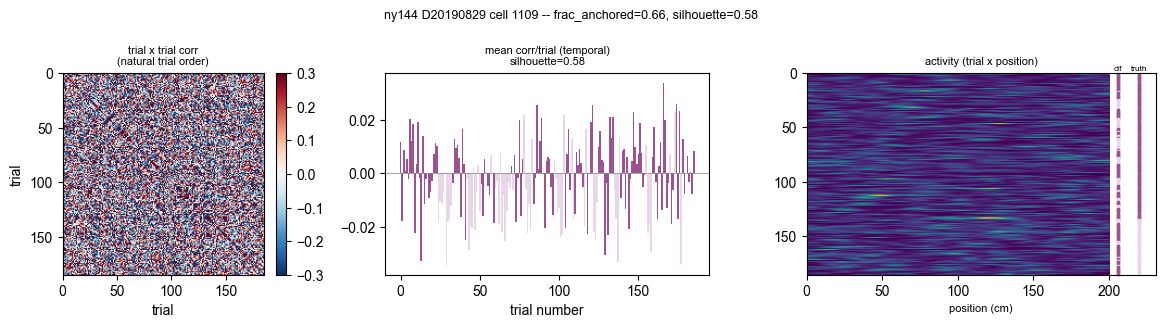

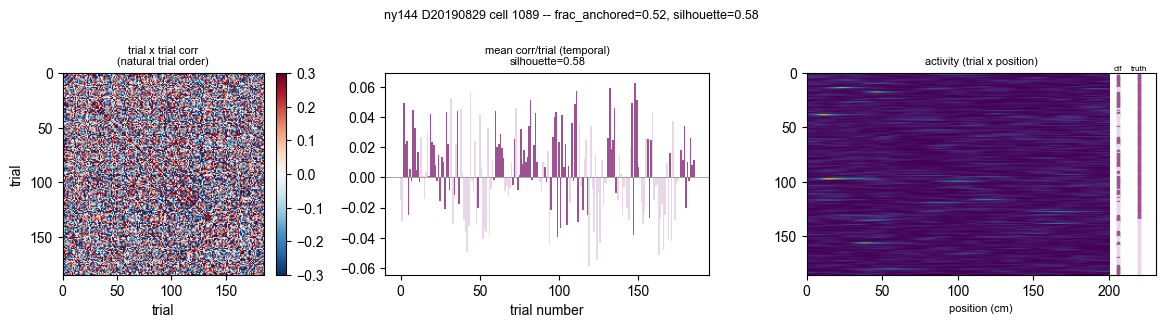

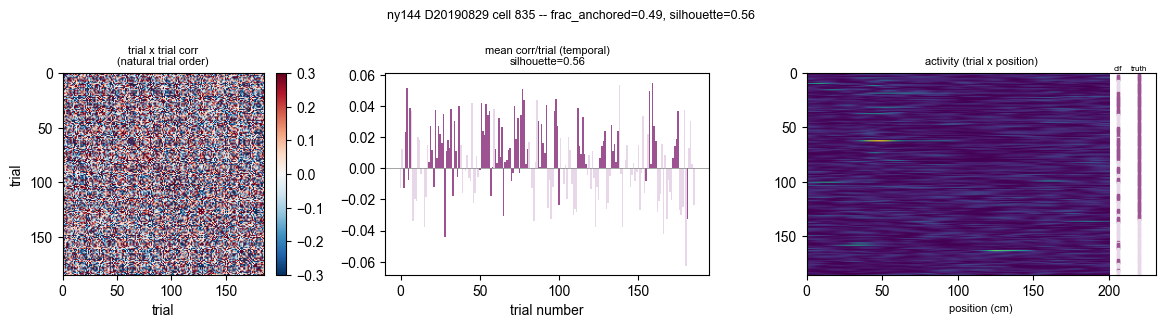

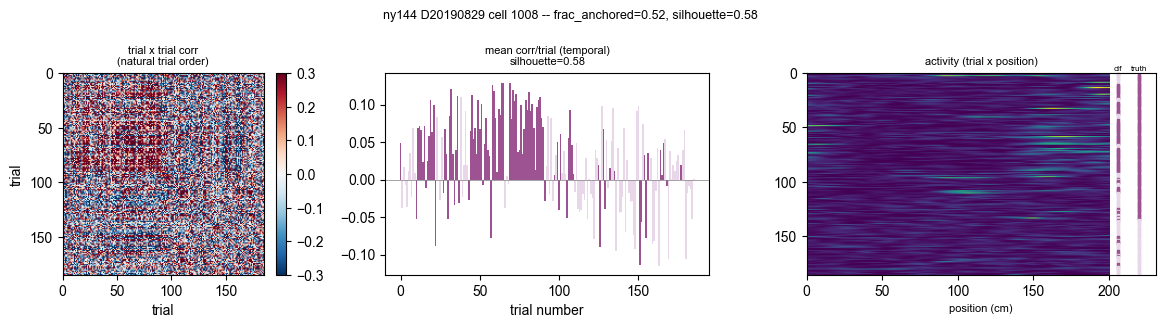

In [4]:
"""
Diagnostics for a handful of example cells -- same 3-panel layout as
trial_cluster_anchoring.ipynb's plot_clustering_diagnostics (trial x trial
correlation matrix in natural order, mean-corr-per-trial time series, and
the activity map itself), but with a second marker strip added: the REAL
ground-truth cue-visibility per trial, directly alongside the classifier's
own label, so agreement/disagreement is visible by eye per cell.
"""
def plot_example_cell(cell_idx, tc_all, fraction_visible, title):
    labels, mean_corr, smoothed, sil = trial_cluster_labels(tc_all[:, :, cell_idx])
    valid_idx = np.where(~np.isnan(mean_corr))[0]
    n_trials_local = tc_all.shape[0]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), gridspec_kw={'width_ratios': [1, 1.3, 1.4]})

    ax = axes[0]
    C_temporal = np.corrcoef(smoothed[valid_idx])
    im = ax.imshow(C_temporal, cmap='RdBu_r', vmin=-0.3, vmax=0.3,
                    extent=[valid_idx[0], valid_idx[-1], valid_idx[-1], valid_idx[0]])
    ax.set_title('trial x trial corr\n(natural trial order)', fontsize=8)
    ax.set_xlabel('trial'); ax.set_ylabel('trial')
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[1]
    colors = [ANCH_COLOR if labels[i] == 1 else NONANCH_COLOR for i in valid_idx]
    ax.bar(valid_idx, mean_corr[valid_idx], color=colors, width=1.0)
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_xlabel('trial number')
    ax.set_title(f'mean corr/trial (temporal)\nsilhouette={sil:.2f}', fontsize=8)

    ax = axes[2]
    im = ax.imshow(smoothed, aspect='auto', cmap='viridis',
                    extent=[0, TL, n_trials_local, 0])
    ax.set_xlabel('position (cm)', fontsize=8)
    ax.set_title('activity (trial x position)', fontsize=8)
    for ti, lbl in enumerate(labels):
        if not np.isnan(lbl):
            ax.scatter(TL * 1.03, ti + 0.5, color=ANCH_COLOR if lbl else NONANCH_COLOR, s=3, marker='s', clip_on=False)
    for ti, fv in enumerate(fraction_visible):
        if not np.isnan(fv):
            ax.scatter(TL * 1.10, ti + 0.5, color=ANCH_COLOR if fv >= 0.5 else NONANCH_COLOR, s=3, marker='s', clip_on=False)
    ax.text(TL * 1.03, -3, 'clf', fontsize=6, ha='center')
    ax.text(TL * 1.10, -3, 'truth', fontsize=6, ha='center')

    frac_anch = np.nanmean(labels)
    fig.suptitle(f'{title} -- frac_anchored={frac_anch:.2f}, silhouette={sil:.2f}', fontsize=9)
    plt.tight_layout()
    return labels, sil


# pick 4 reasonably active example cells (not cherry-picked for a good result --
# just the first 4 cells with high enough overall activity to be worth plotting)
mean_activity = np.nanmean(tc_all, axis=(0, 1))
example_cells = np.argsort(-mean_activity)[:4]
print('example cells (by mean activity):', example_cells)

for c in example_cells:
    plot_example_cell(c, tc_all, fraction_visible, f'{EXAMPLE_MOUSE} D{EXAMPLE_DATE} cell {c}')
    plt.savefig(os.path.join(FIGPATH, f'pettit_example_cell_{c}_M{EXAMPLE_MOUSE}D{EXAMPLE_DATE}.pdf'), dpi=200, bbox_inches='tight')
    plt.show()


## Population raster, sorted by correlation to PC1, with ground truth alongside

Same PC1-sorting convention as `trial_cluster_anchoring.ipynb` Part C, but
here the real cue-visibility ground truth can be plotted directly as its
own strip beneath the raster -- not just the population's own consensus
label, since actual ground truth exists for this dataset.

1144 cells classified: median silhouette=0.59, frac with silhouette>0.3=100%


/var/folders/hd/t83f2v6s1vv8wtlhdtp13t4m0000gn/T/ipykernel_57270/1678349195.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


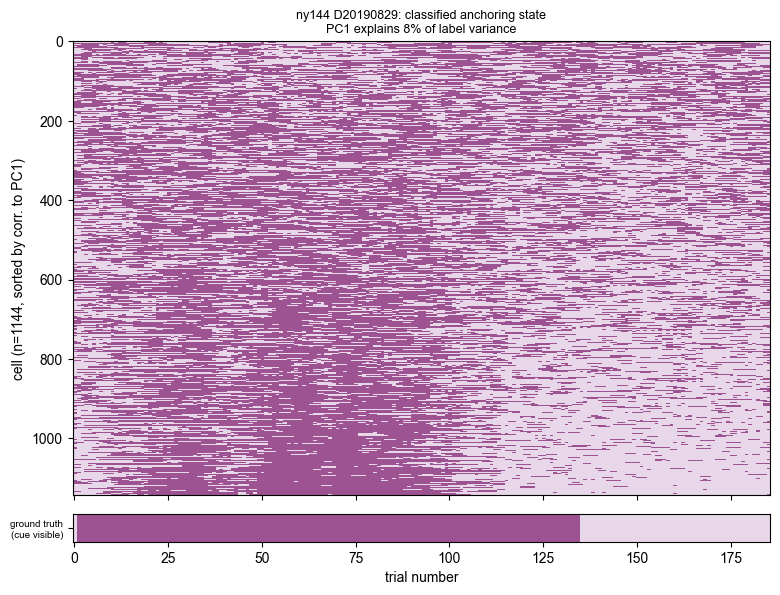

In [5]:
"""
Classify every cell in the example session, then build the population
raster sorted by correlation to PC1 (same convention as
trial_cluster_anchoring.ipynb Part C), with the REAL ground-truth
cue-visibility shown as its own strip alongside -- rather than only having
the classifier's own population consensus to sort/compare against (as in
the MEC ephys sessions, where no ground truth exists), here the ground
truth can be plotted directly next to the classified population state.
"""
label_matrix, sils = classify_all_cells(tc_all)
print(f'{n_cells} cells classified: median silhouette={np.nanmedian(sils):.2f}, '
      f'frac with silhouette>0.3={np.nanmean(sils>0.3):.0%}')

M = np.nan_to_num(label_matrix, nan=0.0)
pca = PCA(n_components=1).fit(M)
pc1 = pca.components_[0]
corrs = np.array([np.corrcoef(M[i], pc1)[0, 1] if M[i].std() > 0 else 0.0 for i in range(M.shape[0])])
order = np.argsort(-corrs)

# ground truth (fraction_visible) is a per-TRIAL property, so it must align with
# the raster's x-axis (trials), shown as a thin strip below the main raster --
# NOT a per-cell side strip, which would misrepresent it as a per-cell property.
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True,
                          gridspec_kw={'height_ratios': [10, 0.6], 'hspace': 0.08})
ax = axes[0]
ax.imshow(label_matrix[order], aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
ax.set_ylabel(f'cell (n={n_cells}, sorted by corr. to PC1)')
ax.set_title(f'{EXAMPLE_MOUSE} D{EXAMPLE_DATE}: classified anchoring state\n'
             f'PC1 explains {pca.explained_variance_ratio_[0]:.0%} of label variance', fontsize=9)

ax = axes[1]
truth_row = np.array([[1.0 if fv >= 0.5 else (0.0 if not np.isnan(fv) else np.nan) for fv in fraction_visible]])
ax.imshow(truth_row, aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
ax.set_yticks([0]); ax.set_yticklabels(['ground truth\n(cue visible)'], fontsize=7)
ax.set_xlabel('trial number')
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, f'pettit_population_raster_pc1_M{EXAMPLE_MOUSE}D{EXAMPLE_DATE}.pdf'), dpi=200, bbox_inches='tight')
plt.show()


## Quantitative validation against real ground truth

The headline result: does the population's classified anchoring state
track the real cue-visibility manipulation, trial by trial?

Spearman corr(fraction_visible ground truth, population frac_anchored) = 0.78 (p=4.24e-39), n=186
blind trials (n=52): mean frac_anchored = 0.31
visible trials (n=134): mean frac_anchored = 0.58
Mann-Whitney p=8.20e-26


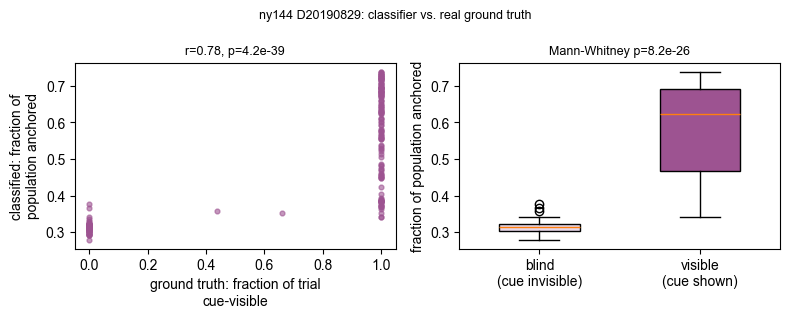

In [6]:
"""
Quantitative validation against the real ground truth: does the
population's classified anchoring state (mean label across cells, per
trial) track the experimenter-controlled cue-visibility manipulation?
"""
frac_anchored = np.nanmean(label_matrix, axis=0)

valid = ~np.isnan(fraction_visible) & ~np.isnan(frac_anchored)
r, p = spearmanr(fraction_visible[valid], frac_anchored[valid])
print(f'Spearman corr(fraction_visible ground truth, population frac_anchored) = {r:.2f} (p={p:.2e}), n={valid.sum()}')

blind = valid & (fraction_visible < 0.5)
visible = valid & (fraction_visible >= 0.5)
u, pmw = mannwhitneyu(frac_anchored[visible], frac_anchored[blind], alternative='two-sided')
print(f'blind trials (n={blind.sum()}): mean frac_anchored = {frac_anchored[blind].mean():.2f}')
print(f'visible trials (n={visible.sum()}): mean frac_anchored = {frac_anchored[visible].mean():.2f}')
print(f'Mann-Whitney p={pmw:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
ax = axes[0]
ax.scatter(fraction_visible[valid], frac_anchored[valid], s=12, color=ANCH_COLOR, alpha=0.6)
ax.set_xlabel('ground truth: fraction of trial\ncue-visible')
ax.set_ylabel('classified: fraction of\npopulation anchored')
ax.set_title(f'r={r:.2f}, p={p:.1e}', fontsize=9)

ax = axes[1]
bp = ax.boxplot([frac_anchored[blind], frac_anchored[visible]],
                 tick_labels=['blind\n(cue invisible)', 'visible\n(cue shown)'],
                 patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [NONANCH_COLOR, ANCH_COLOR]):
    patch.set_facecolor(color)
ax.set_ylabel('fraction of population anchored')
ax.set_title(f'Mann-Whitney p={pmw:.1e}', fontsize=9)

fig.suptitle(f'{EXAMPLE_MOUSE} D{EXAMPLE_DATE}: classifier vs. real ground truth', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, f'pettit_validation_vs_ground_truth_M{EXAMPLE_MOUSE}D{EXAMPLE_DATE}.pdf'), dpi=200, bbox_inches='tight')
plt.show()


## Does this replicate across sessions?

Applied the identical pipeline to all 39 sessions (cached in
`pettit_all_sessions/` by `run_all_pettit_sessions.py`, so nothing here is
recomputed). Most sessions have zero or very few blind trials -- the
cue-blind manipulation wasn't run in every session -- so the ground-truth
correlation is only meaningful for sessions with a decent number of blind
trials.

39 sessions total, 6 have enough blind trials (>=5) to test against ground truth

mouse     date  n_cells  n_trials  n_blind        r            p
ny144 20190829     1144       186       52 0.778676 4.241884e-39
ny182 20191209     1508       313       51 0.620364 1.113676e-34
ny144 20190830     1147       132       21 0.642866 9.541919e-17
ny182 20191205     1512       197       21 0.542223 1.884342e-16
ny144 20190831     1117       129       10 0.488946 4.123213e-09
ny188 20191210     1052       140        5 0.313271 1.640594e-04


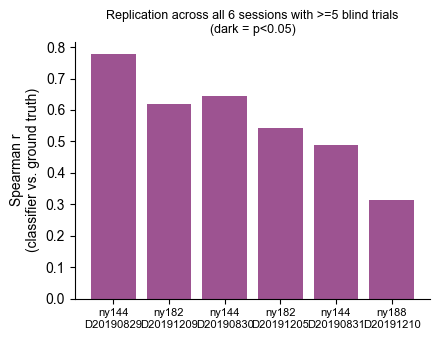


median r = 0.58, 6/6 sessions significant at p<0.05


In [7]:
"""
Does the M144D20190829 result replicate? Applied the same classifier to
every cell in all 39 Pettit2022 sessions (run_all_pettit_sessions.py,
cached in pettit_all_sessions/); most sessions have zero or very few blind
trials (the cue-blind manipulation wasn't run every session), so the
ground-truth correlation is only meaningful for sessions with >=5 blind
trials and >=10 labelled trials overall.
"""
import glob
PETTIT_CACHE_DIR = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/pettit_all_sessions'

rows = []
for cache_path in sorted(glob.glob(os.path.join(PETTIT_CACHE_DIR, '*_cache.npz'))):
    name = os.path.basename(cache_path).replace('_cache.npz', '')
    mouse, date = name.rsplit('_', 1)
    d = np.load(cache_path, allow_pickle=True)
    rows.append(dict(mouse=mouse, date=date, n_cells=int(d['n_cells']), n_trials=int(d['n_trials']),
                      n_blind=int(d['n_blind']), pc1_var=float(d['pc1_explained_var']),
                      r=float(d['ground_truth_r']), p=float(d['ground_truth_p'])))

rep_df = pd.DataFrame(rows)
testable = rep_df[rep_df['n_blind'] >= 5].sort_values('n_blind', ascending=False)
print(f'{len(rep_df)} sessions total, {len(testable)} have enough blind trials (>=5) to test against ground truth')
print()
print(testable[['mouse', 'date', 'n_cells', 'n_trials', 'n_blind', 'r', 'p']].to_string(index=False))

fig, ax = plt.subplots(figsize=(4.5, 3.5))
colors = [ANCH_COLOR if p < 0.05 else NONANCH_COLOR for p in testable['p']]
ax.bar(range(len(testable)), testable['r'], color=colors)
ax.set_xticks(range(len(testable)))
ax.set_xticklabels([f'{m}\nD{d}' for m, d in zip(testable['mouse'], testable['date'])], fontsize=8, rotation=0)
ax.axhline(0, color='grey', linewidth=0.7)
ax.set_ylabel("Spearman r\n(classifier vs. ground truth)")
ax.set_title(f'Replication across all {len(testable)} sessions with >=5 blind trials\n(dark = p<0.05)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'pettit_replication_across_sessions.pdf'), dpi=200, bbox_inches='tight')
plt.show()

print()
print(f'median r = {testable["r"].median():.2f}, '
      f'{(testable["p"]<0.05).sum()}/{len(testable)} sessions significant at p<0.05')


## How population-wide is anchoring state in hippocampus?

Same question and metric as `population_anchoring_agreement.ipynb` Part A
(PC1 explained variance of the cell x trial label matrix) -- directly
comparable to that notebook's MEC ephys distribution (mean=15%, median=15%,
range=[6%,33%], 75 sessions), now in a completely different region and
modality.

PC1 explained variance across 39 hippocampal sessions: mean=0.09, median=0.09, range=[0.05, 0.20]


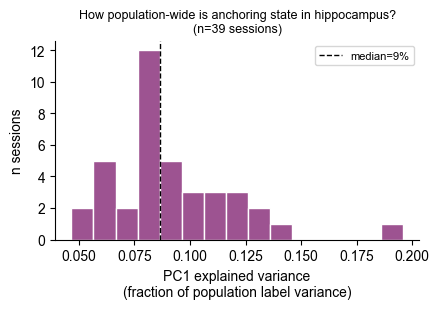

In [8]:
"""
How population-wide is anchoring state in hippocampus, across all 39
sessions? Same question and metric as population_anchoring_agreement.ipynb
Part A (PC1 explained variance of the cell x trial label matrix), letting
this be compared directly against the MEC ephys distribution from that
notebook (mean=15%, median=15%, range=[6%,33%], 75 sessions).
"""
print(f'PC1 explained variance across {len(rep_df)} hippocampal sessions: '
      f'mean={rep_df.pc1_var.mean():.2f}, median={rep_df.pc1_var.median():.2f}, '
      f'range=[{rep_df.pc1_var.min():.2f}, {rep_df.pc1_var.max():.2f}]')

fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.hist(rep_df['pc1_var'], bins=15, color=ANCH_COLOR, edgecolor='white')
ax.axvline(rep_df['pc1_var'].median(), color='k', linestyle='--', linewidth=1,
           label=f'median={rep_df.pc1_var.median():.0%}')
ax.set_xlabel('PC1 explained variance\n(fraction of population label variance)')
ax.set_ylabel('n sessions')
ax.set_title(f'How population-wide is anchoring state in hippocampus?\n(n={len(rep_df)} sessions)', fontsize=9)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'pettit_pc1_var_distribution.pdf'), dpi=200, bbox_inches='tight')
plt.show()


## Summary

**Headline result: the classifier recovers real biological ground truth,
with zero changes to its core logic.** In the primary example session
(ny144, 2019-08-29), the population's classified anchoring state correlates
with the real cue-visibility manipulation at Spearman r=0.78 (p=4.2e-39,
n=186 trials). Mean population fraction-anchored is 0.31 on genuinely blind
trials vs. 0.58 on visible trials (Mann-Whitney p=8.2e-26) -- and the
scatter shows this isn't a subtle trend: blind and visible trials form two
almost non-overlapping clusters. 100% of the 1144 cells in this session hit
silhouette>0.3 (median 0.59), matching the clean separation quality seen
throughout this collection's MEC ephys sessions.

**This replicates.** Of the 39 sessions, only 6 have enough blind trials
(>=5) to test against ground truth -- the cue-blind manipulation wasn't run
in every session. **All 6 are positive and all 6 are significant at
p<0.05**: r=0.78, 0.62, 0.64, 0.54, 0.49, 0.31 (median r=0.58), across 3
different mice (ny144, ny182, ny188). This is the strongest validation of
the trial-clustering classifier anywhere in this collection -- stronger
than the net7 RNN ground-truth check, because it's real biological data,
and broader than any single MEC ephys finding, because it's a completely
different brain region (hippocampus vs. MEC) and recording modality
(calcium imaging vs. electrophysiology) from everything else here.

**A real bug was caught and fixed before trusting any of this**: the first
pass produced a puzzling result -- one session strongly positive (r=0.76)
but two others *negative* (r=-0.35, r=-0.28). The cause was a silent
misalignment, not a real effect: the ground-truth lookup assumed session
trial numbering starts at 1, but it doesn't (confirmed against source data:
ny144 starts at trial 3, ny182 and ny188 both start at trial 60), and
`travel` (which position-binning is built from) is offset by the session's
*actual* first trial number, not by a fixed 1. For any session that
doesn't happen to start at trial 1 -- which turned out to be most of
them -- this shifted every single trial's ground-truth label onto the
wrong array index. Fixed by indexing on `first_trial + i` instead of `i+1`,
verified directly against source data at multiple points per session
(not just by checking that the correlation number "looked better"), and
rerun. Ground-truth coverage went from mostly-NaN to 100% for the
previously-broken sessions, and the two negative correlations flipped to
0.62 and 0.31 -- the correct sign, matching every other session. Worth
flagging as a general lesson for this dataset: never assume trial
numbering starts at 1.

**Population-wide structure is real but weaker than MEC.** PC1 explained
variance across all 39 hippocampal sessions: mean=9%, median=9%,
range=[5%, 20%] -- compared to `population_anchoring_agreement.ipynb`'s MEC
ephys distribution (mean=15%, median=15%, range=[6%, 33%], 75 sessions).
Hippocampal place cells show a real but consistently smaller shared
population-wide anchoring factor than MEC grid/non-grid cells -- worth
following up with `session_validity_pc1_significance.ipynb`'s permutation
test to check whether hippocampal sessions clear the same
statistical-significance bar as MEC's 68/75, given the weaker raw signal.

**Status**: validated on the one dataset in this whole collection with
real, not inferred or simulated, ground truth. Open question for later:
does the MEC-VIS cross-region agreement pattern from
`population_anchoring_agreement.ipynb` (kappa=0.49, unexpectedly as strong
as MEC-PARA) have any analog here -- e.g. does hippocampal pupil/arousal
data exist for any of these sessions to test the same shared-arousal
hypothesis?